In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
# plt.rcParams['image.cmap'] = 'magma'

from scipy import signal
from skimage import io
from tqdm import tqdm

import import_helper
import_helper.add_functions()
import organoid_analysis.geometrical_organoid_analysis as geo
import organoid_analysis.utils as u

### Obtain Width of TBXT Peaks

Obtain contour of neuruloids and plot intensity curve.
Obtain full width half maximum of the peak.

In [2]:
# function to loop through all the image data and save in dataframe
def tbxt_width_analysis(result_path):
    excel_path = "tbxt_width_data_1.xlsx" # excel with information of images
    data_df = pd.read_excel(excel_path)
    list_of_image_names = data_df["name"].to_list() # obtain list of image names
    true_diameters = data_df["true_diameter"].to_list()

    results_df = pd.DataFrame({"name":list_of_image_names, "true_diameter":true_diameters})
    fitted_diameter = np.zeros(len(list_of_image_names))
    tbxt_prop = np.zeros(len(list_of_image_names))
    tbxt_width = np.zeros(len(list_of_image_names))

    for i in tqdm(range(len(list_of_image_names))):
        image_name = list_of_image_names[i]
        DAPI_img_path = f"../data/tbxt_width_data_1/DAPI_images/{image_name}"
        TBXT_img_path = f"../data/tbxt_width_data_1/TBXT_images/{image_name}"

        if os.path.exists(DAPI_img_path) and os.path.exists(TBXT_img_path):
            DAPI_channel = io.imread(DAPI_img_path, as_gray=True)
            TBXT_channel = io.imread(TBXT_img_path, as_gray=True)
            dx = data_df.loc[data_df['name'] == image_name, 'dx'].iloc[0]

            DAPI_bin = geo.get_binary_image(DAPI_channel, 
                                            intensity_threshold=500,
                                            binary_dilation_iter=10,
                                            binary_closing_iter=20)
            contour, center = geo.get_contour_and_centroid(DAPI_bin, 
                                                        smoothing_factor=10**4)

            distances = np.linalg.norm(contour - center, axis=1)
            max_dist = distances[np.argmax(distances)]
            min_dist = distances[np.argmin(distances)]
            radius = int((0.5*max_dist + 0.5*min_dist))
            diameter = radius*2*dx

            radii_res = np.linspace(0, radius, radius+1) #np.arange(0, radius+1, 1) # discretisation for radius
            n_output = 50 # number of segments to get mean
            norm_dist = np.linspace(0, 1, n_output+1)[1:] # normalised distance 
            angle_res = 500 # number of intensity lines to plot
            angles = np.linspace(0, 2*np.pi, angle_res+1)[:-1]

            TBXT_intensity = geo.get_intensities_array(TBXT_channel,
                                                       contour,
                                                       0,
                                                       center,
                                                       radii_res,
                                                       angles)
            mean_TBXT_intensity = geo.mean_ignore_zeros(TBXT_intensity)
            TBXT = geo.mean_intensity_segments_ignore_zero(mean_TBXT_intensity, n_output)

            peaks = signal.find_peaks(TBXT)[0]
            max_peak = peaks[np.argmax(TBXT[peaks])]
            peak_width = signal.peak_widths(TBXT, np.array([max_peak]))
            fwhm = u.index_to_xdata(norm_dist, peak_width[0])

            # save data
            fitted_diameter[i], tbxt_prop[i], tbxt_width[i] = diameter, fwhm, fwhm*radius*dx

        else:
            fitted_diameter[i], tbxt_prop[i], tbxt_width[i] = None, None, None

    results_df["fitted_diameter"] = fitted_diameter
    results_df["tbxt_prop"] = tbxt_prop
    results_df["tbxt_size"] = tbxt_width

    results_df.to_csv(result_path)
    
# tbxt_width_analysis("../tbxt_width_dataframes/tbxt_width_1.csv")

### Analysing each image

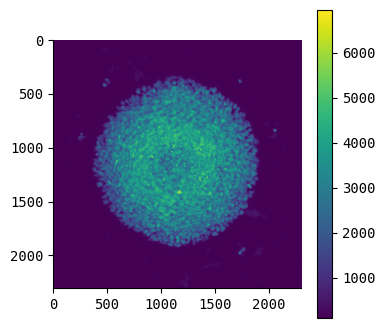

In [3]:
folder = "../example_data"
image_name = "example.tif"
DAPI_img_path = os.path.join(folder, f"DAPI_images/{image_name}")
DAPI_channel = io.imread(DAPI_img_path, as_gray=True)
TBXT_img_path = os.path.join(folder, f"TBXT_images/{image_name}")
TBXT_channel = io.imread(TBXT_img_path, as_gray=True)
dx = 0.214815 # discretisation

fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(DAPI_channel)
fig.colorbar(im)

763
(2304, 2304)


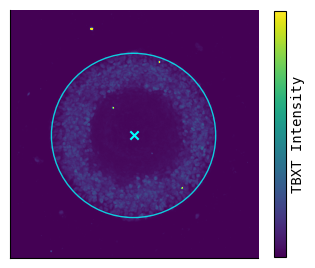

In [4]:
DAPI_bin = geo.get_binary_image(DAPI_channel, 
                                intensity_threshold=500, #20, #000, #50,  #10
                                binary_dilation_iter=10,
                                binary_closing_iter=20)
contour, center = geo.get_contour_and_centroid(DAPI_bin, smoothing_factor=10**4)

distances = np.linalg.norm(contour - center, axis=1)
max_dist = distances[np.argmax(distances)]
min_dist = distances[np.argmin(distances)]
radius = int((0.5*max_dist + 0.5*min_dist))
print(radius)
print(np.shape(TBXT_channel))

from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(TBXT_channel, 
               vmin=np.percentile(DAPI_channel, 1), 
               vmax=np.percentile(DAPI_channel, 99),
               origin="lower")
# ax.scatter(contour[:,1], contour[:,0], s=0.01, color="orange", alpha=0.5)
ax.scatter(center[1], center[0], marker="x", color="cyan")
ax.set_yticks([])
ax.set_xticks([])
circle = Circle((center[1], center[0]), radius, alpha=0.8, color="cyan", fill=False)
ax.add_patch(circle)
# ax.set_xlim(120, 1032)
# ax.set_ylim(120, 1032)
cb = fig.colorbar(im, label="TBXT Intensity", shrink=0.8)
cb.set_ticks([])
# cb.ax.tick_params(labelsize=10) 
cb.set_label(label="TBXT Intensity", size=10)
# fig.savefig("fit_circle.png", transparent=True)

In [5]:
radii_res = np.linspace(0, radius, radius+1) #np.arange(0, radius+1, 1) # discretisation for radius
n_output = 50 # number of segments to get mean
norm_dist = np.linspace(0, 1, n_output+1)[1:] # normalised distance 
angle_res = 500 # number of intensity lines to plot
angles = np.linspace(0, 2*np.pi, angle_res+1)[:-1]

TBXT_intensity = geo.get_intensities_array(TBXT_channel,
                                           contour,
                                           0,
                                           center,
                                           radii_res,
                                           angles)
mean_TBXT_intensity = geo.mean_ignore_zeros(TBXT_intensity)
TBXT = geo.mean_intensity_segments_ignore_zero(mean_TBXT_intensity, n_output)

[]

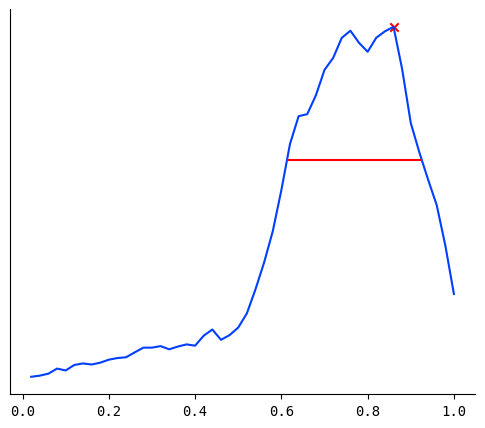

In [6]:
# plot intensity of TBXT get FWHM
peaks = signal.find_peaks(TBXT)[0]
max_peak = peaks[np.argmax(TBXT[peaks])]
peak_width = signal.peak_widths(TBXT, np.array([max_peak]))
fwhm = u.index_to_xdata(norm_dist, peak_width[0])

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(norm_dist, TBXT, label="TBXT_signal")
ax.scatter(norm_dist[max_peak], TBXT[max_peak], marker="x", color="red")
ax.hlines(*(peak_width[1], u.index_to_xdata(norm_dist, peak_width[2]), u.index_to_xdata(norm_dist, peak_width[3])), 
          color="red")
ax.set_yticks([])
# ax.legend()

### Group multiple csv files of TBXT width data and plot in one figure

In [7]:
FOLDER = "../tbxt_width_dataframes"
files = [file for file in os.listdir(FOLDER) if file.endswith(".csv")]
dfs = [pd.read_csv(os.path.join(FOLDER, file))for file in files]
full_df = pd.concat(dfs)
full_df = full_df.dropna()
print(files)

['tbxt_width_2.csv', 'tbxt_width_1.csv']


In [8]:
# fit linear line and get slope
print(full_df.head())

y_data = full_df["tbxt_size"].to_numpy()
true_diameter = full_df["fitted_diameter"].to_numpy()
fitted_diameter = full_df["true_diameter"].to_numpy()

slope, intercept, r = u.fit_linear_line_and_evaluate(fitted_diameter, y_data)
print(slope, intercept, r)

   Unnamed: 0                                               name  \
0           0  MAX_Process_2023.08.18_RH001_20x_circle_400_01_01   
1           1  MAX_Process_2023.08.18_RH001_20x_circle_400_02_01   
2           2  MAX_Process_2023.08.18_RH001_20x_circle_500_01_01   
3           3  MAX_Process_2023.08.18_RH001_20x_circle_500_02_01   
4           4   MAX_Process_20230817_RH001_20x_circle_size_01_01   

   true_diameter  fitted_diameter  tbxt_prop  tbxt_size  
0            350         307.4222   0.335163  51.518330  
1            350         317.6910   0.321067  51.000005  
2            500         465.9468   0.214964  50.080797  
3            500         475.5738   0.318109  75.642077  
4            500         478.7828   0.286248  68.525249  
0.03837829574254627 40.37998863651113 0.14305131401829718


(0.0, 80.0)

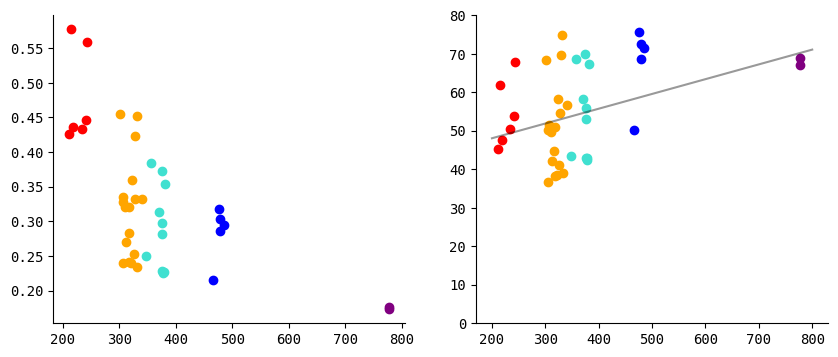

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
# marker_map = {250 : 'o', 350: '^', 400: 's', 500: 'x', 800:'+'}
color_map = {250:'red', 350:'orange', 400:'turquoise', 500:'blue', 800:'purple'}

n_data = {}
for size, df in full_df.groupby('true_diameter'):
    # plot by mean and std
    prop = df["tbxt_prop"].to_numpy()
    n_data[size] = len(prop)
    mean = np.nanmean(prop)
    sd = np.nanstd(prop)
    # ax[0].errorbar(x=size, y=mean, yerr=sd, fmt="o", marker=marker_map[size], color=color_map[size])

    tbxt_size = df["tbxt_size"].to_numpy()
    mean = np.nanmean(tbxt_size)
    sd = np.nanstd(tbxt_size)
    # ax[1].errorbar(x=size, y=mean, yerr=sd, fmt="o", marker=marker_map[size], color=color_map[size])
    im = ax[0].scatter(x=df["fitted_diameter"], y=df["tbxt_prop"], color=color_map[size], label=f"{size}") #, cmap="cool") #, vmin=min_time, vmax=max_time)
    im1 = ax[1].scatter(x=df["fitted_diameter"], y=df["tbxt_size"], color=color_map[size], label=f"{size}")#, cmap="cool") #, vmin=min_time, vmax=max_time)

size_range = np.linspace(200, 800, 10)
ax[1].plot(size_range, slope*size_range+intercept, color="black", alpha=0.4)
# make legend from scratch
import matplotlib.lines as mlines
handles = []
for key in color_map:
    marker = mlines.Line2D([], [], color=color_map[size], linestyle='None', markersize=6, label=f"{key}, n={n_data[key]}")
    handles.append(marker)
# ax[1].legend(handles=handles, title="Micropattern \nDiameter ($\mu$m)", loc="lower right")
ax[1].set_ylim(0, 80)

(0.0, 80.0)

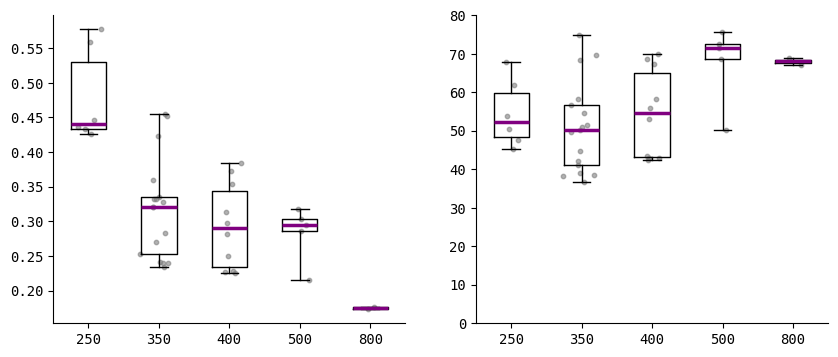

In [10]:
# to plot box plots 
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

micropattern_sizes = []
tbxt_size_data = []
tbxt_prop_data = []
for size, df in full_df.groupby('true_diameter'):
    micropattern_sizes.append(size)
    prop = df["tbxt_prop"].to_numpy()
    tbxt_prop_data.append(prop)
    tbxt_size = df["tbxt_size"].to_numpy()
    tbxt_size_data.append(tbxt_size)

# make legend from scratch
meanlineprops = dict(linestyle='-', linewidth=2.5, color='purple')
ax[0].boxplot(tbxt_prop_data, showfliers=False, whis=[0, 100], tick_labels=micropattern_sizes, medianprops=meanlineprops)
for i, data in enumerate(tbxt_prop_data, start=1):
    jittered_x = np.random.normal(i, 0.08, size=len(data))  # Add jitter to x
    ax[0].scatter(jittered_x, data, color='gray', alpha=0.6, s=10)
ax[1].boxplot(tbxt_size_data, showfliers=False, whis=[0, 100], tick_labels=micropattern_sizes, medianprops=meanlineprops)
for i, data in enumerate(tbxt_size_data, start=1):
    jittered_x = np.random.normal(i, 0.08, size=len(data))  # Add jitter to x
    ax[1].scatter(jittered_x, data, color='gray', alpha=0.6, s=10)
ax[1].set_ylim(0, 80)